In [148]:
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[0]
sys.path.append(str(ROOT_DIR))

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams["figure.dpi"] = 300
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']
import pandas as pd
import numpy as np

from src.data.pmodel_generation import (
    generate_and_prepare_series,
)

In [149]:
np.random.seed(47)  # For reproducibility

In [150]:
serie = generate_and_prepare_series(1024, 0.45, peak_percentile=99.99)

In [151]:
serie

,raw,normalized,peak,peak_threshold
0,0.788083,0.191266,0,0.978511
1,0.646613,0.128252,0,0.978511
2,0.530865,0.076696,0,0.978511
3,0.646613,0.128252,0,0.978511
4,0.436163,0.034513,0,0.978511
...,...,...,...,...
1019,0.530865,0.076696,0,0.978511
1020,0.436163,0.034513,0,0.978511
1021,0.530865,0.076696,0,0.978511
1022,0.530865,0.076696,0,0.978511


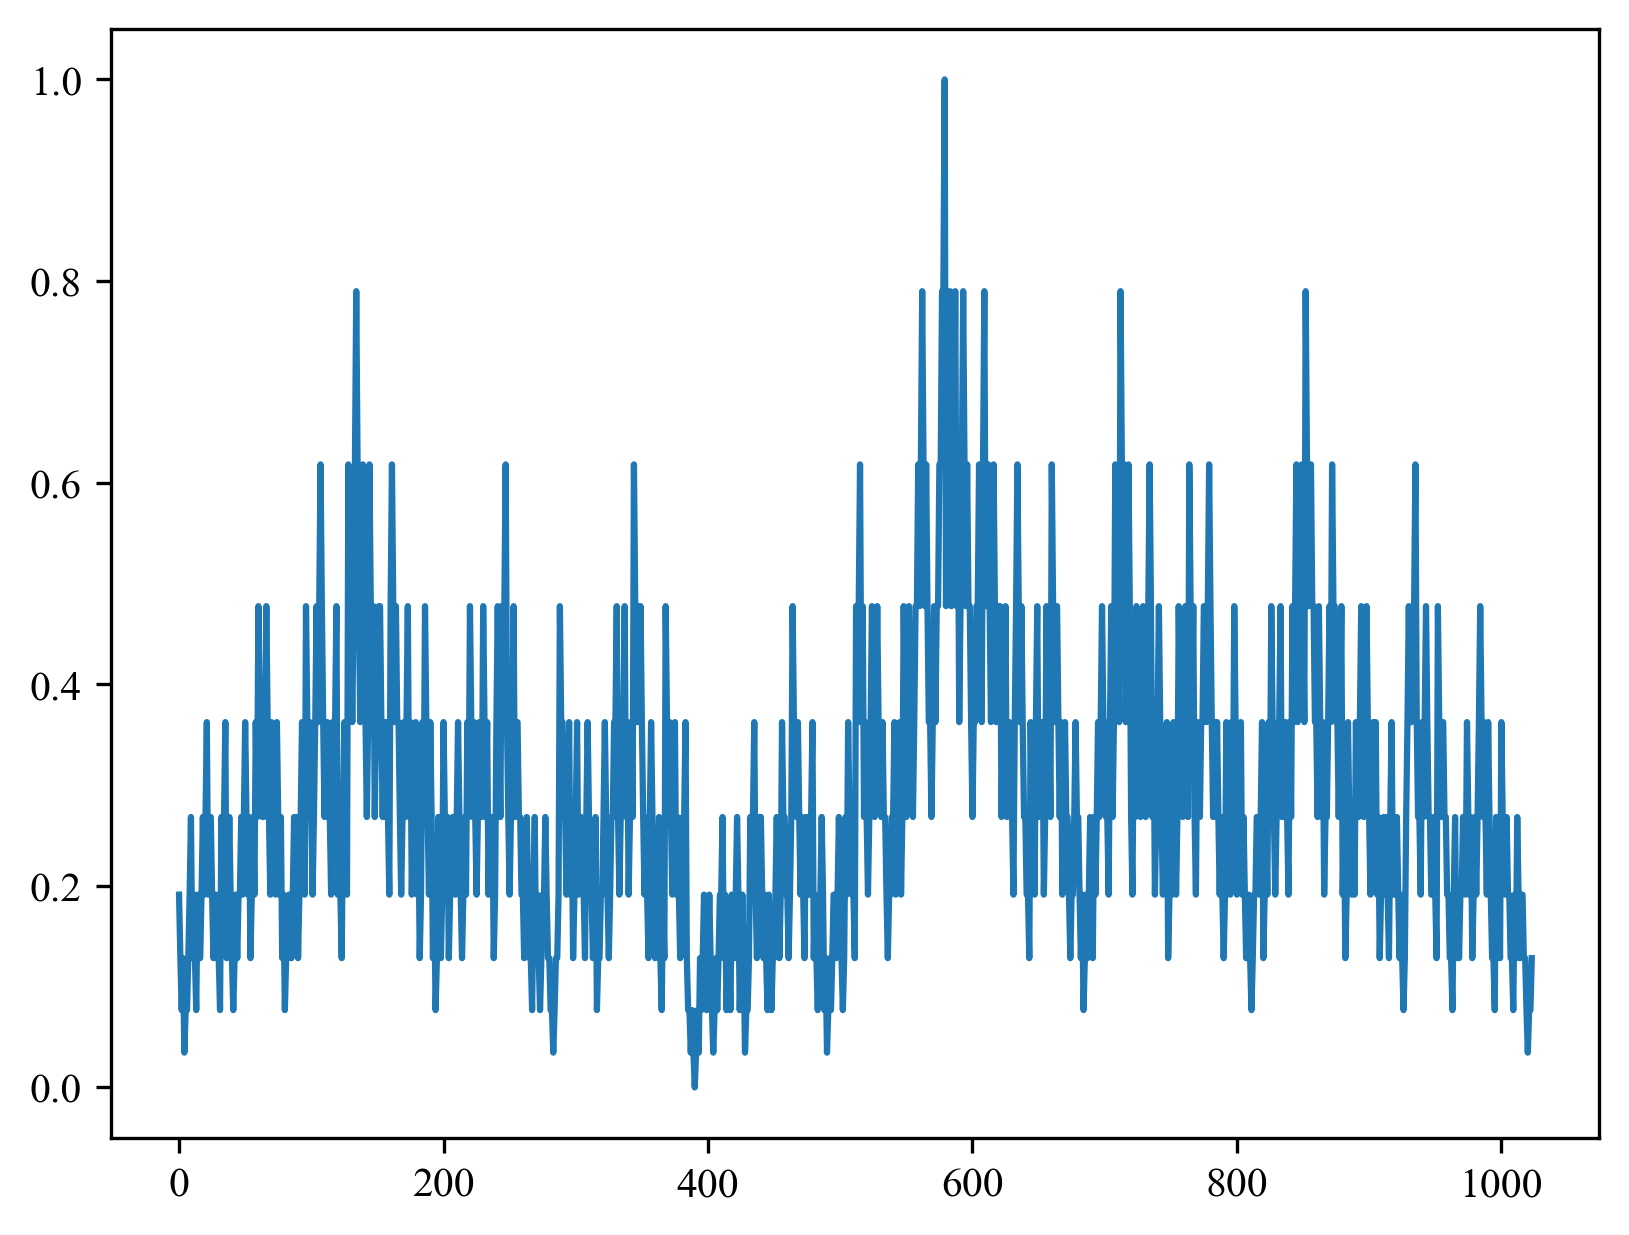

In [152]:
plt.plot(serie["normalized"])

In [153]:
df = pd.DataFrame(
    serie,
    columns=["raw", "normalized", "peak", "peak_threshold"]
)


In [154]:
peak_indices = df.index[df["peak"] == 1].to_numpy()


In [155]:
T_BEFORE = 100   # pontos antes do pico
T_AFTER  = 100   # pontos depois do pico


In [156]:
import numpy as np
import pandas as pd

windows = []

for tc in peak_indices:
    start = tc - T_BEFORE
    end   = tc + T_AFTER

    # garantir que a janela não sai da série
    if start < df.index.min() or end > df.index.max():
        continue

    segment = df.loc[start:end, "normalized"].copy()
    
    # construir τ
    tau = segment.index.to_numpy() - tc
    
    window_df = pd.DataFrame({
        "tau": tau,
        "value": segment.values,
        "tc": tc
    })
    
    windows.append(window_df)


In [157]:
ensemble_df = pd.concat(windows, ignore_index=True)
ensemble_df

,tau,value,tc
0,-100,0.362414,579
1,-99,0.128252,579
2,-98,0.191266,579
3,-97,0.128252,579
4,-96,0.076696,579
...,...,...,...
196,96,0.191266,579
197,97,0.191266,579
198,98,0.268282,579
199,99,0.362414,579


In [158]:
before = ensemble_df[ensemble_df["tau"] < 0]
after  = ensemble_df[ensemble_df["tau"] > 0]


In [159]:
TAU_MIN = 3   # ajuste isso depois


In [160]:
import numpy as np

mean_before = (
    ensemble_df[ensemble_df["tau"] < -TAU_MIN]
    .assign(abs_tau=lambda x: np.abs(x["tau"]))
    .groupby("abs_tau")["value"]
    .mean()
)

mean_after = (
    ensemble_df[ensemble_df["tau"] > TAU_MIN]
    .assign(abs_tau=lambda x: x["tau"])
    .groupby("abs_tau")["value"]
    .mean()
)


In [161]:
from scipy.stats import linregress

def fit_power_law(x, y):
    logx = np.log(x)
    logy = np.log(y)
    slope, intercept, r_value, p_value, std_err = linregress(logx, logy)
    return -slope, r_value**2


In [162]:
p_before, r2_before = fit_power_law(
    mean_before.index.values,
    mean_before.values
)

p_after, r2_after = fit_power_law(
    mean_after.index.values,
    mean_after.values
)


In [163]:
print(f"p_before = {p_before:.3f} (R²={r2_before:.3f})")
print(f"p_after  = {p_after:.3f} (R²={r2_after:.3f})")


p_before = 0.462 (R²=0.372)
p_after  = 0.317 (R²=0.365)


In [164]:
theta_exo = 1 - p_after
theta_endo_before = (1 - p_before) / 2
theta_endo_after  = (1 - p_after) / 2


In [165]:
print("θ (exo)       =", theta_exo)
print("θ (endo,bef) =", theta_endo_before)
print("θ (endo,aft) =", theta_endo_after)


θ (exo)       = 0.6831574936096567
θ (endo,bef) = 0.269020939950539
θ (endo,aft) = 0.34157874680482836


In [166]:
symmetry_ratio = p_before / p_after
print("p_before / p_after =", symmetry_ratio)


p_before / p_after = 1.4580055099355875


/opt/homebrew/Caskroom/miniconda/base/envs/aedeep/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10216 (\N{MATHEMATICAL LEFT ANGLE BRACKET}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/aedeep/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


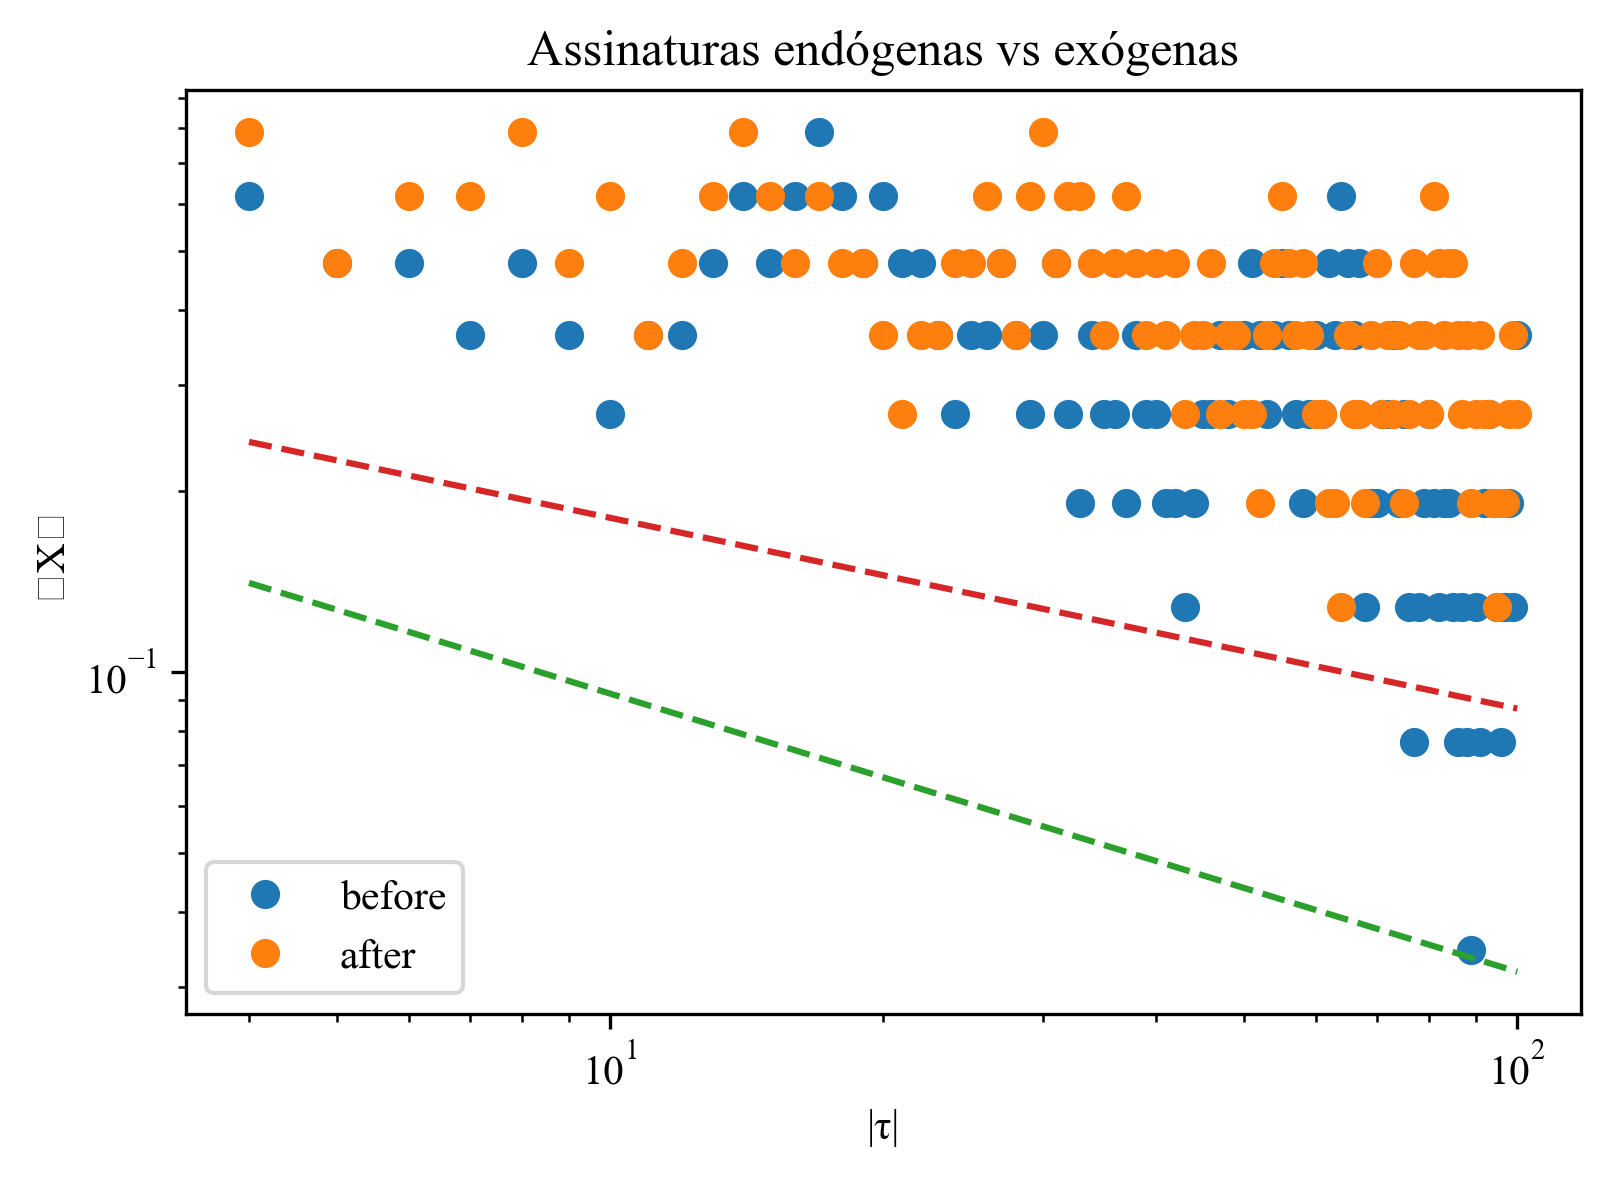

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.loglog(mean_before.index, mean_before.values, 'o', label='before')
plt.loglog(mean_after.index, mean_after.values, 'o', label='after')

# linhas ajustadas
plt.loglog(
    mean_before.index,
    np.exp(np.log(mean_before.index)*(-p_before) + np.log(mean_before.values).mean()),
    '--'
)

plt.loglog(
    mean_after.index,
    np.exp(np.log(mean_after.index)*(-p_after) + np.log(mean_after.values).mean()),
    '--'
)

plt.legend()
plt.xlabel('|τ|')
plt.ylabel('⟨X⟩')
plt.title('Assinaturas endógenas vs exógenas')
plt.show()


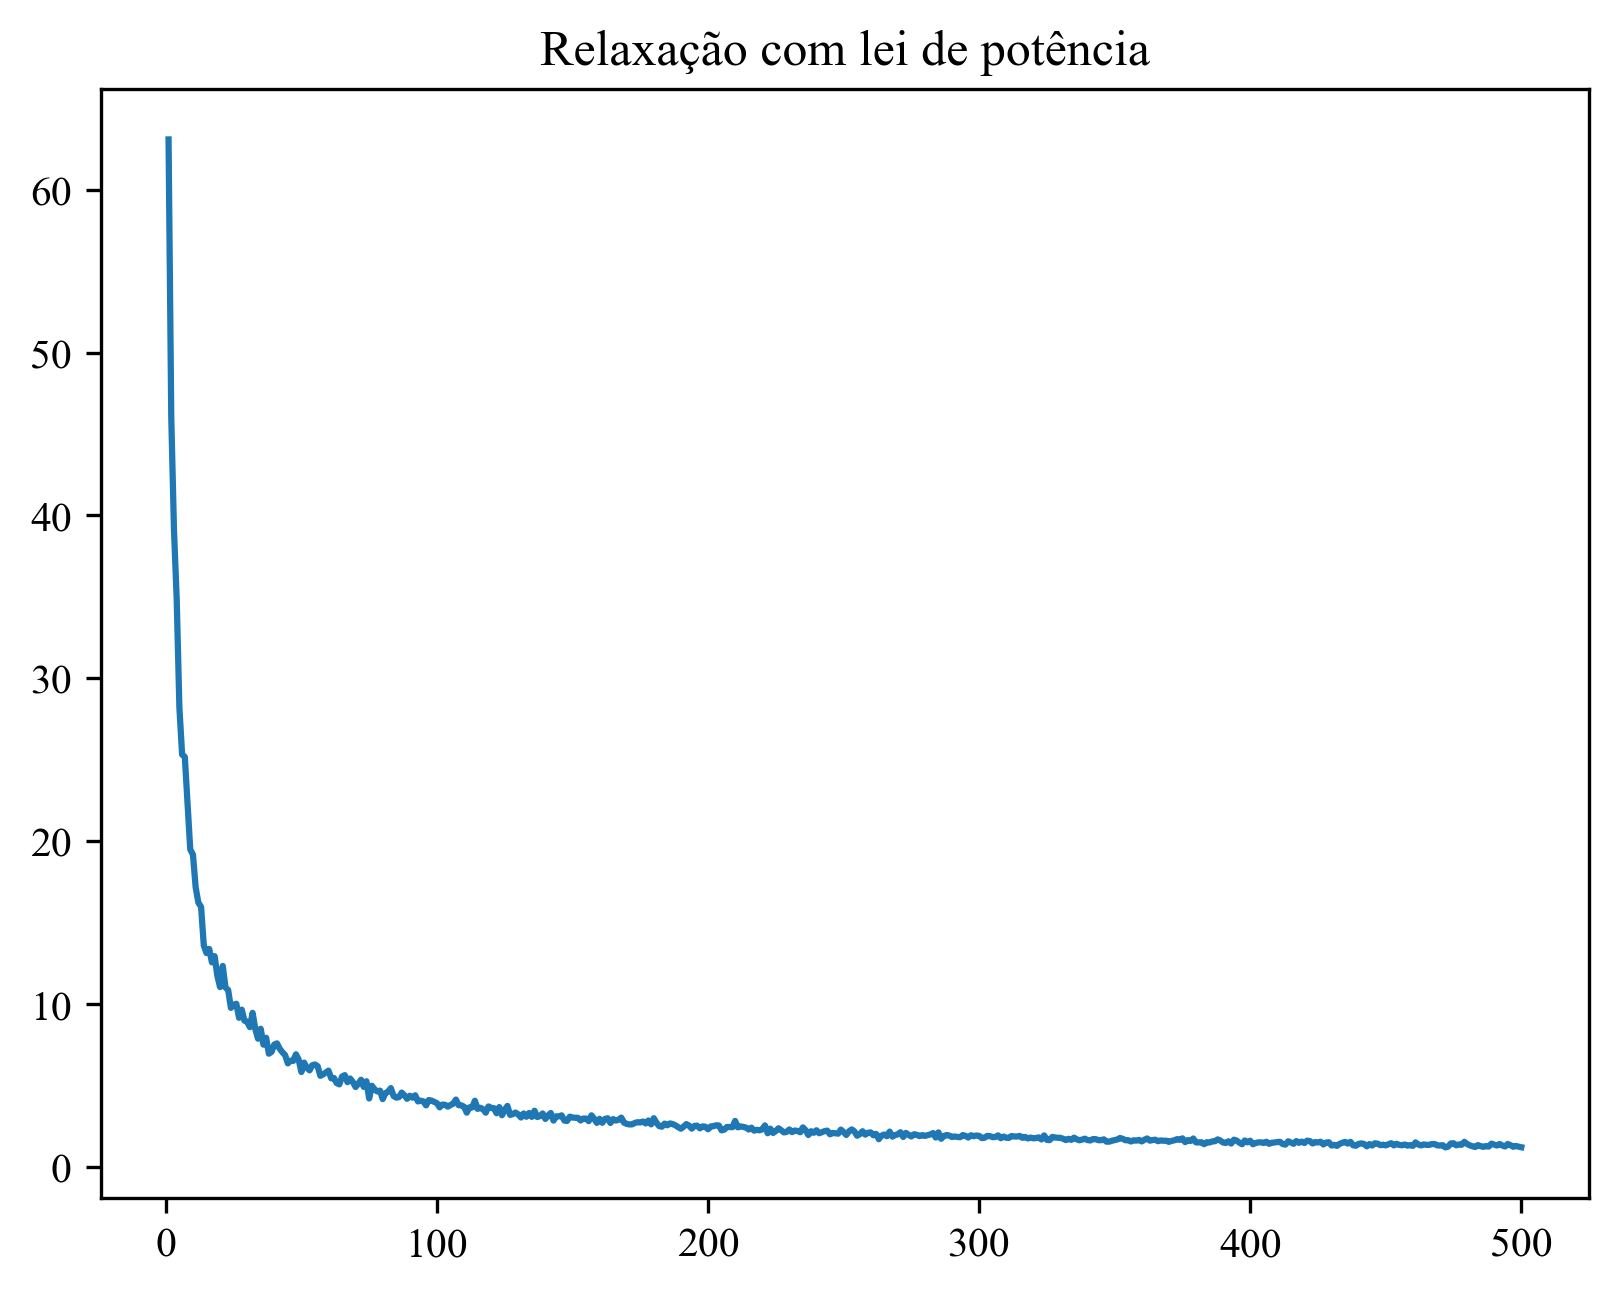

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

np.random.seed(42)

# -----------------------
# Parâmetros
# -----------------------
T = 500
p_true = 0.7     # expoente verdadeiro (exógeno com theta=0.3)
A = 100
c = 1

t = np.arange(1, T+1)

# lei de potência + ruído multiplicativo leve
signal = A / (t + c)**p_true
noise = np.random.normal(0, 0.05, size=T)

X = signal * (1 + noise)

# -----------------------
# Visualização
# -----------------------
plt.figure()
plt.plot(t, X)
plt.title("Relaxação com lei de potência")
plt.show()


p verdadeiro = 0.7
p estimado = 0.6783669286365377
R² = 0.9937028602986877


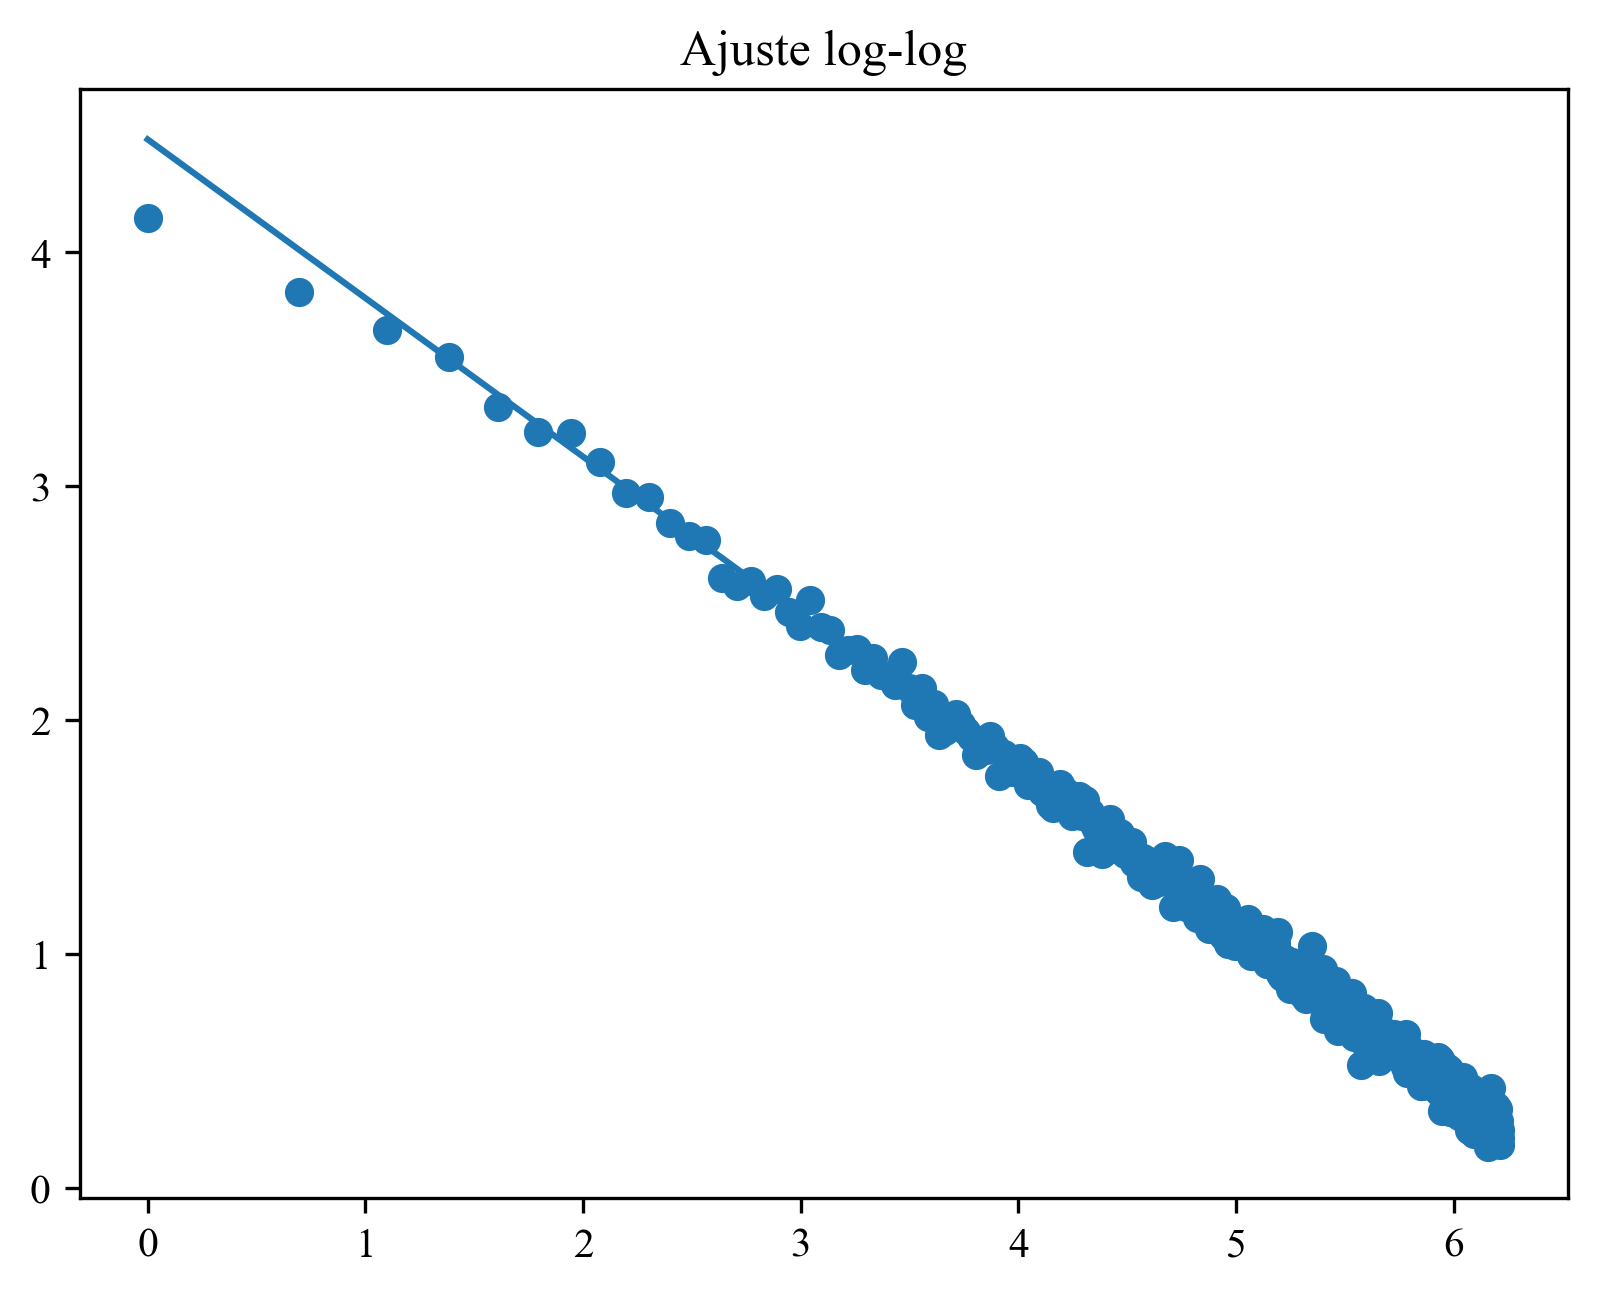

In [179]:
# remover valores negativos
mask = X > 0
t_fit = t[mask]
X_fit = X[mask]

log_t = np.log(t_fit)
log_X = np.log(X_fit)

slope, intercept, r_value, _, _ = linregress(log_t, log_X)

p_est = -slope

print("p verdadeiro =", p_true)
print("p estimado =", p_est)
print("R² =", r_value**2)

plt.figure()
plt.scatter(log_t, log_X)
plt.plot(log_t, intercept + slope*log_t)
plt.title("Ajuste log-log")
plt.show()


Expoente estimado p = -0.0
R² = nan


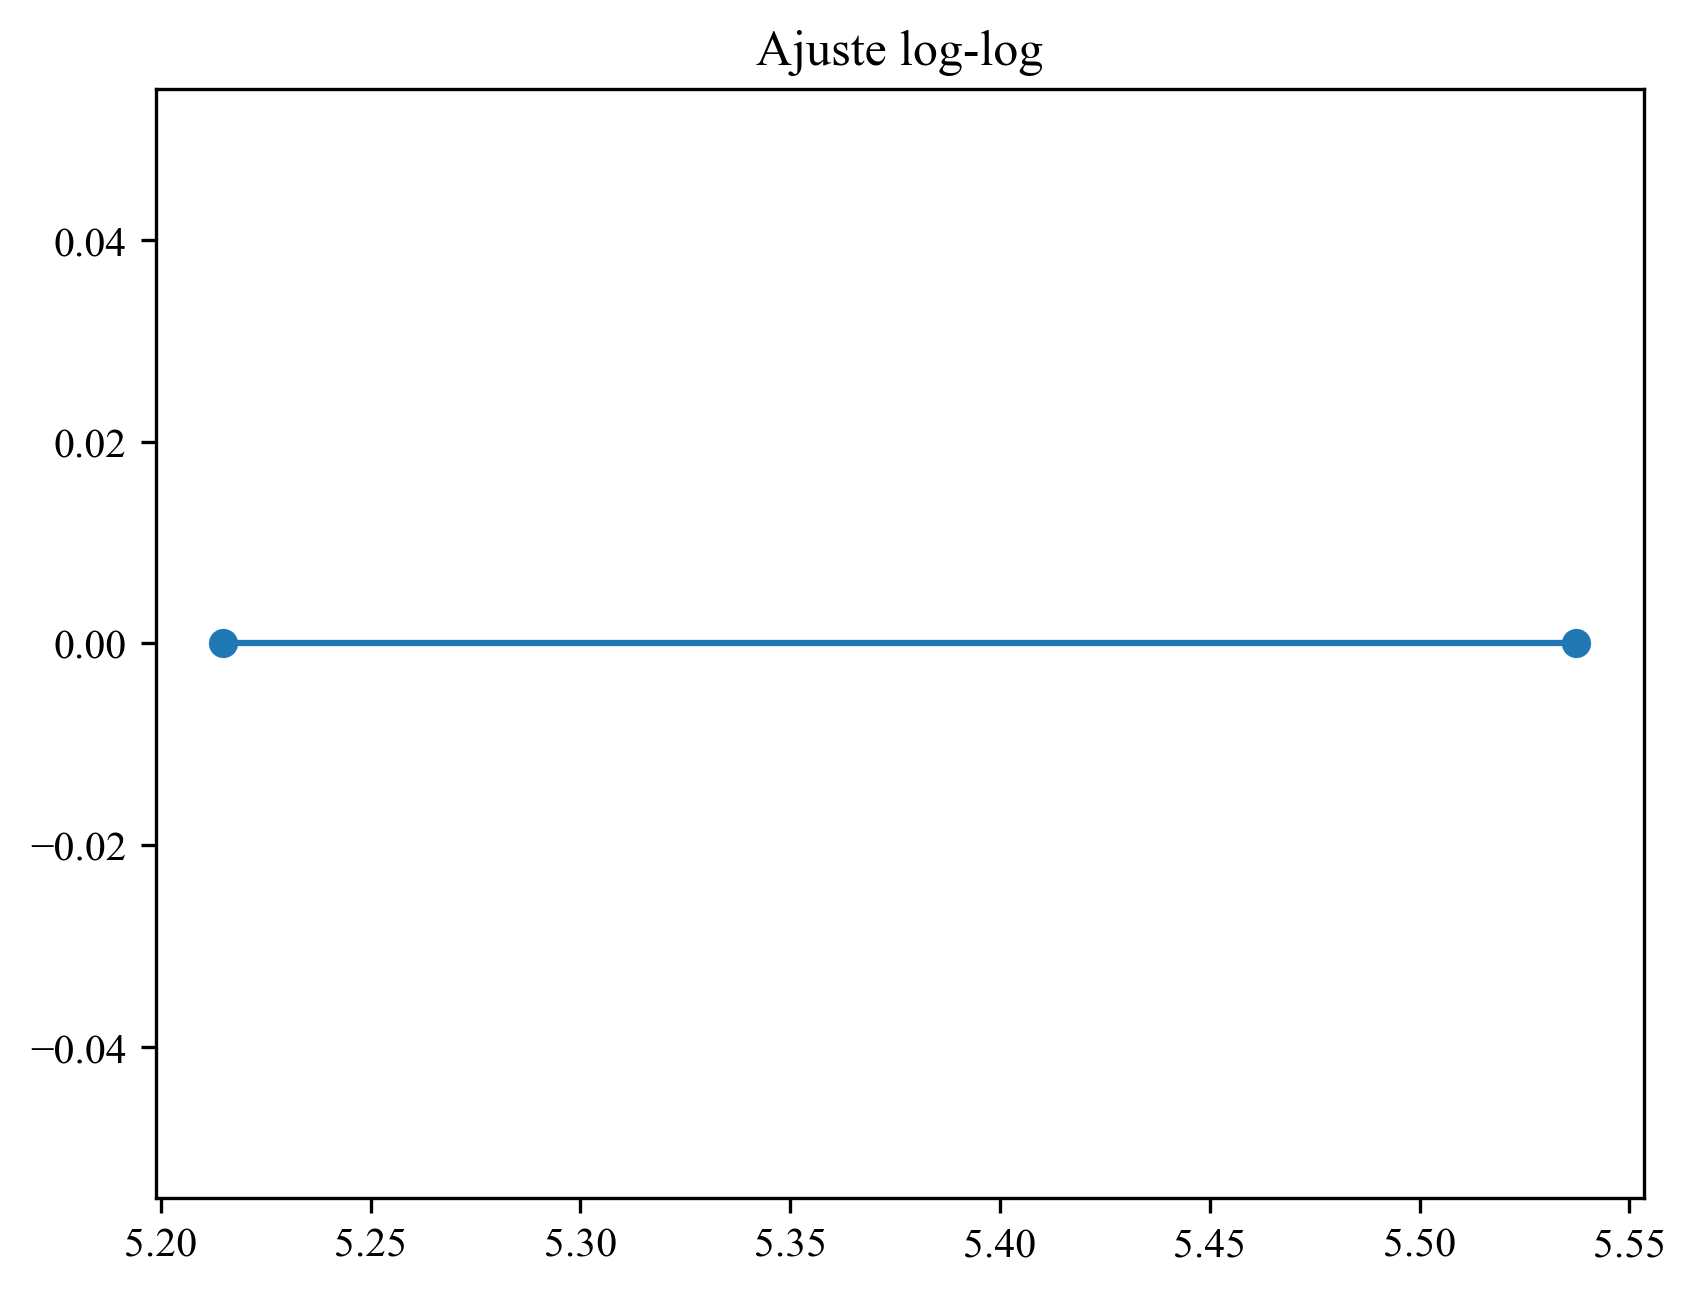

In [180]:
window = 300
t_vals = np.arange(1, window)
relax = events[tc+1:tc+window]

# remover zeros para log
mask = relax > 0
t_vals = t_vals[mask]
relax = relax[mask]

# log-log
log_t = np.log(t_vals)
log_relax = np.log(relax)

slope, intercept, r_value, _, _ = linregress(log_t, log_relax)

p_est = -slope

print("Expoente estimado p =", p_est)
print("R² =", r_value**2)

plt.figure()
plt.scatter(log_t, log_relax)
plt.plot(log_t, intercept + slope*log_t)
plt.title("Ajuste log-log")
plt.show()
